#Primeiro Dataset (parte 1)

Import da base de dados

In [ ]:
from sklearn.datasets import load_wine
import pandas as pd

# Carrega os dados originais
wine = load_wine()

# Transforma em um DataFrame do Pandas para facilitar a visualização
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

# Adiciona a coluna com o alvo (target) - que são as classes de vinho
df_wine['target'] = wine.target

# Mostra as primeiras linhas
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
# 1. Tamanho, Tipo de Informação e Huecos (nulos)
df_wine.info()

# 2. Verificando especificamente se há valores vazios (soma por coluna)
print("\nContagem de valores nulos:")
print(df_wine.isnull().sum())

# 3. Conferindo as Clases (Target)
print("\nClasses presentes no dataset:")
print(df_wine['target'].unique())

print("\nDistribuição das classes:")
print(df_wine['target'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [ ]:
df_wine.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Preprocesamienro (separar en trein i test)[texto do link](https://)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar variáveis preditoras (X) do alvo (y)
X = wine.data
y = wine.target

# 2. Separar em Train (70%) e Test (30%)
# O random_state garante que o resultado seja o mesmo toda vez que rodar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Estandardizar dados (Media 0, Desvio Padrão 1)
scaler = StandardScaler()

# Ajustamos o scaler APENAS com os dados de treino para evitar data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos a mesma transformação aos dados de teste
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train_scaled.shape[0]} amostras")
print(f"Teste: {X_test_scaled.shape[0]} amostras")

Treino: 124 amostras
Teste: 54 amostras


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np # Adicionado para np.isnan

# 1. Realizar Regressão Logística
# Criamos o modelo e o ajustamos com os dados de treino padronizados
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

# Fazemos previsões nos dados de teste
y_pred = model_lr.predict(X_test_scaled)
y_pred_proba = model_lr.predict_proba(X_test_scaled) # Necessário para o AUC

# 2. Revisar Métricas
# Calculamos e exibimos as métricas em uma tabela formatada em roxo
print("\n--- Métricas do Modelo de Regressão Logística ---")

metrics = {
    'Métrica': ['Acurácia (Accuracy)', 'F1-score (Macro)', 'AUC (roc-auc, ovo)'] ,
    'Valor': [
        f"{accuracy_score(y_test, y_pred):.4f}",
        f"{f1_score(y_test, y_pred, average='macro'):.4f}",
        # O AUC para multicaso requer parâmetros específicos
        f"{roc_auc_score(y_test, y_pred_proba, multi_class='ovo', average='macro'):.4f}"
    ]
}

metrics_df = pd.DataFrame(metrics)

# Estilização roxa para a tabela
styled_df = metrics_df.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#673ab7'), ('color', 'white'), ('border-color', '#673ab7')]},
    {'selector': 'td', 'props': [('background-color', '#e1bee7'), ('color', '#4a148c'), ('border-color', '#ba68c8')]}
])

display(styled_df)

# --- Análise adicional de valores faltantes (relacionado ao heatmap) ---
print("\n--- Análise de Valores Faltantes em X_train_missing ---")
total_missing_train = np.isnan(X_train_missing).sum()
print(f"Total de valores faltantes no conjunto de treino (X_train_missing): {total_missing_train}")
if total_missing_train > 0:
    missing_per_column = np.isnan(X_train_missing).sum(axis=0)
    print("Valores faltantes por coluna (X_train_missing):")
    for i, count in enumerate(missing_per_column):
        print(f"  Coluna {i}: {count}")
else:
    print("Nenhum valor faltante detectado em X_train_missing.")


--- Métricas do Modelo de Regressão Logística ---


,Métrica,Valor
0,Acurácia (Accuracy),0.9815
1,F1-score (Macro),0.9804
2,"AUC (roc-auc, ovo)",0.9996



--- Análise de Valores Faltantes em X_train_missing ---
Total de valores faltantes no conjunto de treino (X_train_missing): 490
Valores faltantes por coluna (X_train_missing):
  Coluna 0: 40
  Coluna 1: 41
  Coluna 2: 41
  Coluna 3: 32
  Coluna 4: 42
  Coluna 5: 32
  Coluna 6: 33
  Coluna 7: 39
  Coluna 8: 34
  Coluna 9: 38
  Coluna 10: 37
  Coluna 11: 39
  Coluna 12: 42


In [ ]:
import numpy as np

def eliminar_dados_aleatorios(X_data, porcentagem=0.3):
    # Criamos uma cópia para não sobrescrever os dados originais
    X_missing = X_data.copy()

    # Criamos uma máscara booleana onde True significa "remover"
    mask = np.random.rand(*X_missing.shape) < porcentagem

    # Aplicamos a máscara substituindo os valores por NaN (Not a Number)
    X_missing[mask] = np.nan
    return X_missing

# Aplicar a eliminação (30%) apenas nas variáveis de entrada (X)
X_train_missing = eliminar_dados_aleatorios(X_train_scaled)
X_test_missing = eliminar_dados_aleatorios(X_test_scaled)

# Conferindo se a variável de saída continua intacta
print(f"Total de valores nulos no Treino (X): {np.isnan(X_train_missing).sum()}")
print(f"Total de valores nulos na Saída (y): {np.isnan(y_train).sum()}") # Deve ser 0

Total de valores nulos no Treino (X): 506
Total de valores nulos na Saída (y): 0


heatmap

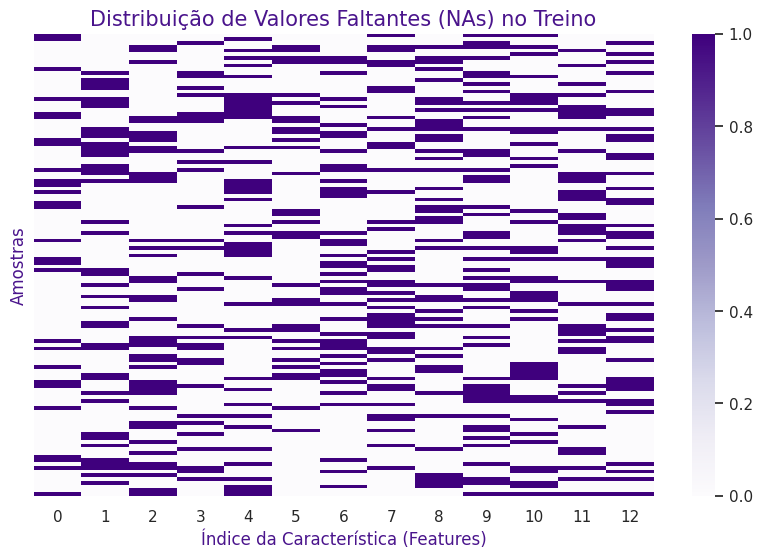

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos o estilo do gráfico
plt.figure(figsize=(10, 6))

# Criamos o heatmap
# yticklabels=False para não poluir o eixo vertical com o índice das 178 linhas
# cbar=False remove a barra lateral de legenda se preferir algo mais limpo
sns.heatmap(pd.DataFrame(X_train_missing).isnull(),
            yticklabels=False,
            cbar=True,
            cmap='Purples') # Tons de roxo

plt.title('Distribuição de Valores Faltantes (NAs) no Treino', color='#4a148c', fontsize=15)
plt.xlabel('Índice da Característica (Features)', color='#4a148c')
plt.ylabel('Amostras', color='#4a148c')

plt.show()

In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer

# 1. Imputação pela Média
imputer_mean = SimpleImputer(strategy='mean')
X_train_mean = imputer_mean.fit_transform(X_train_missing)
X_test_mean = imputer_mean.transform(X_test_missing)

# 2. Imputação por KNN (K-Nearest Neighbors)
# n_neighbors=5 é o padrão, ele olha os 5 vizinhos mais próximos para decidir o valor
imputer_knn = KNNImputer(n_neighbors=5)
X_train_knn = imputer_knn.fit_transform(X_train_missing)
X_test_knn = imputer_knn.transform(X_test_missing)

print("Imputação concluída com sucesso!")

Imputação concluída com sucesso!


In [ ]:
# Função auxiliar para treinar e avaliar de forma rápida
def avaliar_modelo(X_train_data, X_test_data, y_train, y_test):
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_data, y_train)

    y_pred = model.predict(X_test_data)
    y_pred_proba = model.predict_proba(X_test_data)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovo', average='macro')

    return [acc, f1, auc]

# Calculando as métricas para ambos os casos
metricas_media = avaliar_modelo(X_train_mean, X_test_mean, y_train, y_test)
metricas_knn = avaliar_modelo(X_train_knn, X_test_knn, y_train, y_test)

# Organizando os resultados em um DataFrame roxo
resumo_final = pd.DataFrame({
    'Métrica': ['Accuracy', 'F1-Score', 'AUC'],
    'Imputação Média': [f"{m:.4f}" for m in metricas_media],
    'Imputação KNN': [f"{m:.4f}" for m in metricas_knn]
})

# Estilização
styled_resumo = resumo_final.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4a148c'), ('color', 'white')]},
    {'selector': 'td', 'props': [('background-color', '#f3e5f5'), ('color', '#4a148c')]}
])

display(styled_resumo)

,Métrica,Imputação Média,Imputação KNN
0,Accuracy,0.9259,0.8704
1,F1-Score,0.9274,0.8765
2,AUC,0.9875,0.9891


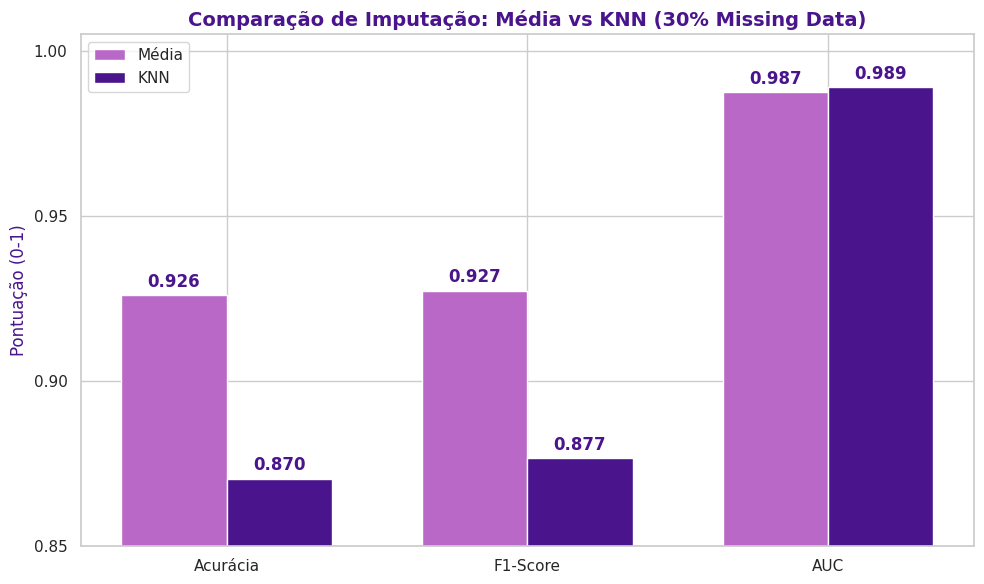

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurações estéticas
sns.set_theme(style="whitegrid")

# Preparação dos dados para o gráfico
categorias = ['Acurácia', 'F1-Score', 'AUC']
x = np.arange(len(categorias))
largura = 0.35

# Plotando as barras
fig, ax = plt.subplots(figsize=(10, 6))
barras1 = ax.bar(x - largura/2, metricas_media, largura, label='Média', color='#ba68c8')
barras2 = ax.bar(x + largura/2, metricas_knn, largura, label='KNN', color='#4a148c')

# Detalhes do gráfico
ax.set_ylabel('Pontuação (0-1)', color='#4a148c', fontsize=12)
ax.set_title('Comparação de Imputação: Média vs KNN (30% Missing Data)', color='#4a148c', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=11)
ax.set_ylim(0.85, 1.005) # Ajustando o limite inferior para focar nas diferenças e o superior para acomodar os valores
ax.set_yticks([0.85, 0.90, 0.95, 1.0]) # Definindo ticks específicos no eixo Y
ax.legend()

# Adicionando os valores em cima das barras para facilitar a leitura
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', color='#4a148c', fontweight='bold')

autolabel(barras1)
autolabel(barras2)

plt.tight_layout()
plt.show()

softimpute e fangyimpute

In [ ]:
!pip install fancyimpute

In [ ]:
from fancyimpute import SoftImpute

# 1. Instanciar o SoftImpute
# O algoritmo usa uma penalidade (threshold) para forçar uma estrutura de baixo ranking (low-rank)
imputer_soft = SoftImpute(verbose=False)

# 2. Aplicar a imputação iterativa
X_train_soft = imputer_soft.fit_transform(X_train_missing)
X_test_soft = imputer_soft.fit_transform(X_test_missing)

print("Imputação SoftImpute concluída!")

# 3. Avaliar o modelo com este novo conjunto
metricas_soft = avaliar_modelo(X_train_soft, X_test_soft, y_train, y_test)

# Adicionando ao nosso resumo comparativo
resumo_final['SoftImpute (PCA)'] = [f"{m:.4f}" for m in metricas_soft]
display(resumo_final.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4a148c'), ('color', 'white')]},
    {'selector': 'td', 'props': [('background-color', '#f3e5f5'), ('color', '#4a148c')]}
]))

Imputação SoftImpute concluída!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

,Métrica,Imputação Média,Imputação KNN,SoftImpute (PCA)
0,Accuracy,0.9259,0.8704,0.9074
1,F1-Score,0.9274,0.8765,0.9073
2,AUC,0.9875,0.9891,0.9928


regressão logistica

In [ ]:
# 1. Calculando as métricas para o modelo original (sem dados faltantes) como base
metricas_original = avaliar_modelo(X_train_scaled, X_test_scaled, y_train, y_test)

# 2. Criando o DataFrame consolidado
comparativo_final = pd.DataFrame({
    'Métrica': ['Acurácia', 'F1-Score', 'AUC'],
    'Original (100% dados)': [f"{m:.4f}" for m in metricas_original],
    'Imputação Média': [f"{m:.4f}" for m in metricas_media],
    'Imputação KNN': [f"{m:.4f}" for m in metricas_knn],
    'SoftImpute (PCA)': [f"{m:.4f}" for m in metricas_soft]
})

# 3. Estilização final em degradê roxo
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #6a1b9a; color: white; font-weight: bold' if v else '' for v in is_max]

styled_final = comparativo_final.style.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4a148c'), ('color', 'white'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '10px')]}
]).set_properties(**{'background-color': '#f3e5f5', 'color': '#4a148c', 'border': '1px solid #ce93d8'})

display(styled_final)

,Métrica,Original (100% dados),Imputação Média,Imputação KNN,SoftImpute (PCA)
0,Acurácia,0.9815,0.9259,0.8704,0.9074
1,F1-Score,0.9804,0.9274,0.8765,0.9073
2,AUC,0.9996,0.9875,0.9891,0.9928


In [ ]:
from sklearn.metrics import mean_squared_error

# Filtrar apenas onde os dados eram originalmente NA para medir o erro de reconstrução
mask_missing = np.isnan(X_train_missing)

# Cálculo do Erro (MSE) entre valores imputados e valores reais (originais)
mse_media = mean_squared_error(X_train_scaled[mask_missing], X_train_mean[mask_missing])
mse_knn = mean_squared_error(X_train_scaled[mask_missing], X_train_knn[mask_missing])
mse_soft = mean_squared_error(X_train_scaled[mask_missing], X_train_soft[mask_missing])

errors = {
    'Método': ['Média', 'KNN', 'SoftImpute (PCA)'],
    'Erro de Reconstrução (MSE)': [mse_media, mse_knn, mse_soft]
}

df_erros = pd.DataFrame(errors)
display(df_erros.style.background_gradient(cmap='Purples'))

,Método,Erro de Reconstrução (MSE)
0,Média,1.126506
1,KNN,0.803694
2,SoftImpute (PCA),0.735632


/tmp/ipykernel_29507/3295647704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Método', y='Erro de Reconstrução (MSE)', data=df_erros, palette='Purples_r')


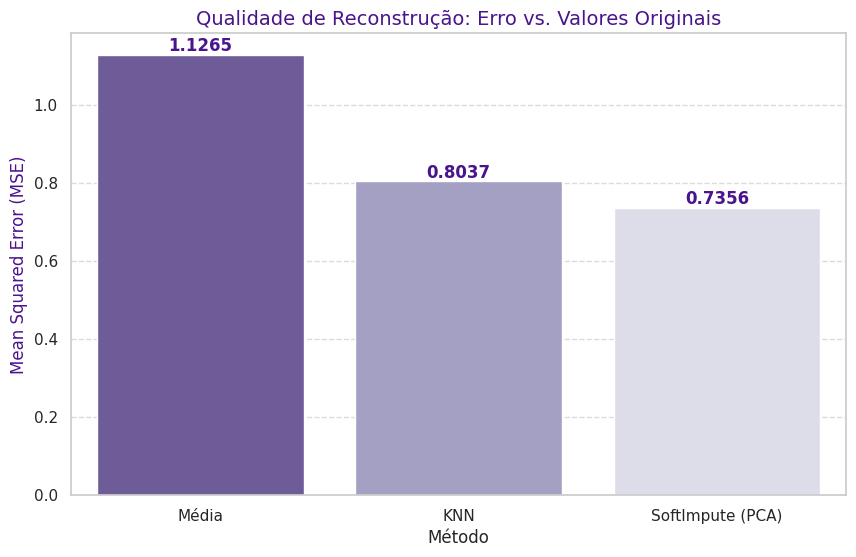

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Método', y='Erro de Reconstrução (MSE)', data=df_erros, palette='Purples_r')

plt.title('Qualidade de Reconstrução: Erro vs. Valores Originais', color='#4a148c', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', color='#4a148c')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionando anotações de valor
for i, v in enumerate(df_erros['Erro de Reconstrução (MSE)']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', color='#4a148c', fontweight='bold')

plt.show()

#Novo dataset (parte 2)

In [ ]:
import pandas as pd

# Reutilizando a movie_matrix que já contém todos os filmes e usuários
# A variável `full_matrix` também já representa isso
full_correlation_matrix = full_matrix.corr()

print(f"Shape da Matriz de Correlação Completa: {full_correlation_matrix.shape}")
print("\nPrimeiras 5 linhas e colunas da Matriz de Correlação Completa:")
display(full_correlation_matrix.head())

Shape da Matriz de Correlação Completa: (1682, 1682)

Primeiras 5 linhas e colunas da Matriz de Correlação Completa:


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
item_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.221784,0.175794,0.103135,0.386475,0.529401,0.159248,0.247367,0.090176,0.187502,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.221784,1.000000,0.230536,0.244556,0.217559,-0.158114,0.175445,0.340525,-0.227599,0.199083,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.175794,0.230536,1.000000,-0.201969,0.184612,0.806226,0.071509,-0.118587,0.016742,0.071563,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.103135,0.244556,-0.201969,1.000000,-0.237350,0.066625,0.152733,0.281270,0.208459,0.231931,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.386475,0.217559,0.184612,-0.237350,1.000000,1.000000,0.180211,0.205114,0.065169,-0.843661,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Como você pode ver, a matriz de correlação completa tem um shape de (1682, 1682), o que significa 1682 filmes por 1682 filmes. Um heatmap dessa dimensão seria impossível de interpretar visualmente. É por isso que geralmente se faz a filtragem para filmes mais populares ou mais relevantes para visualizações e análises de similaridade.

Podemos usar essa matriz para encontrar filmes similares a qualquer outro filme específico, sem a necessidade de visualizá-la por completo. Isso é exatamente o que foi feito no exemplo do "Toy Story" (célula `JEtTkICocMzV`) e também na função `recomendar_filmes` (célula `SxAMOnvofC2e`), que usa as notas preditas de uma matriz completada (resultado do PCA) para fazer recomendações.

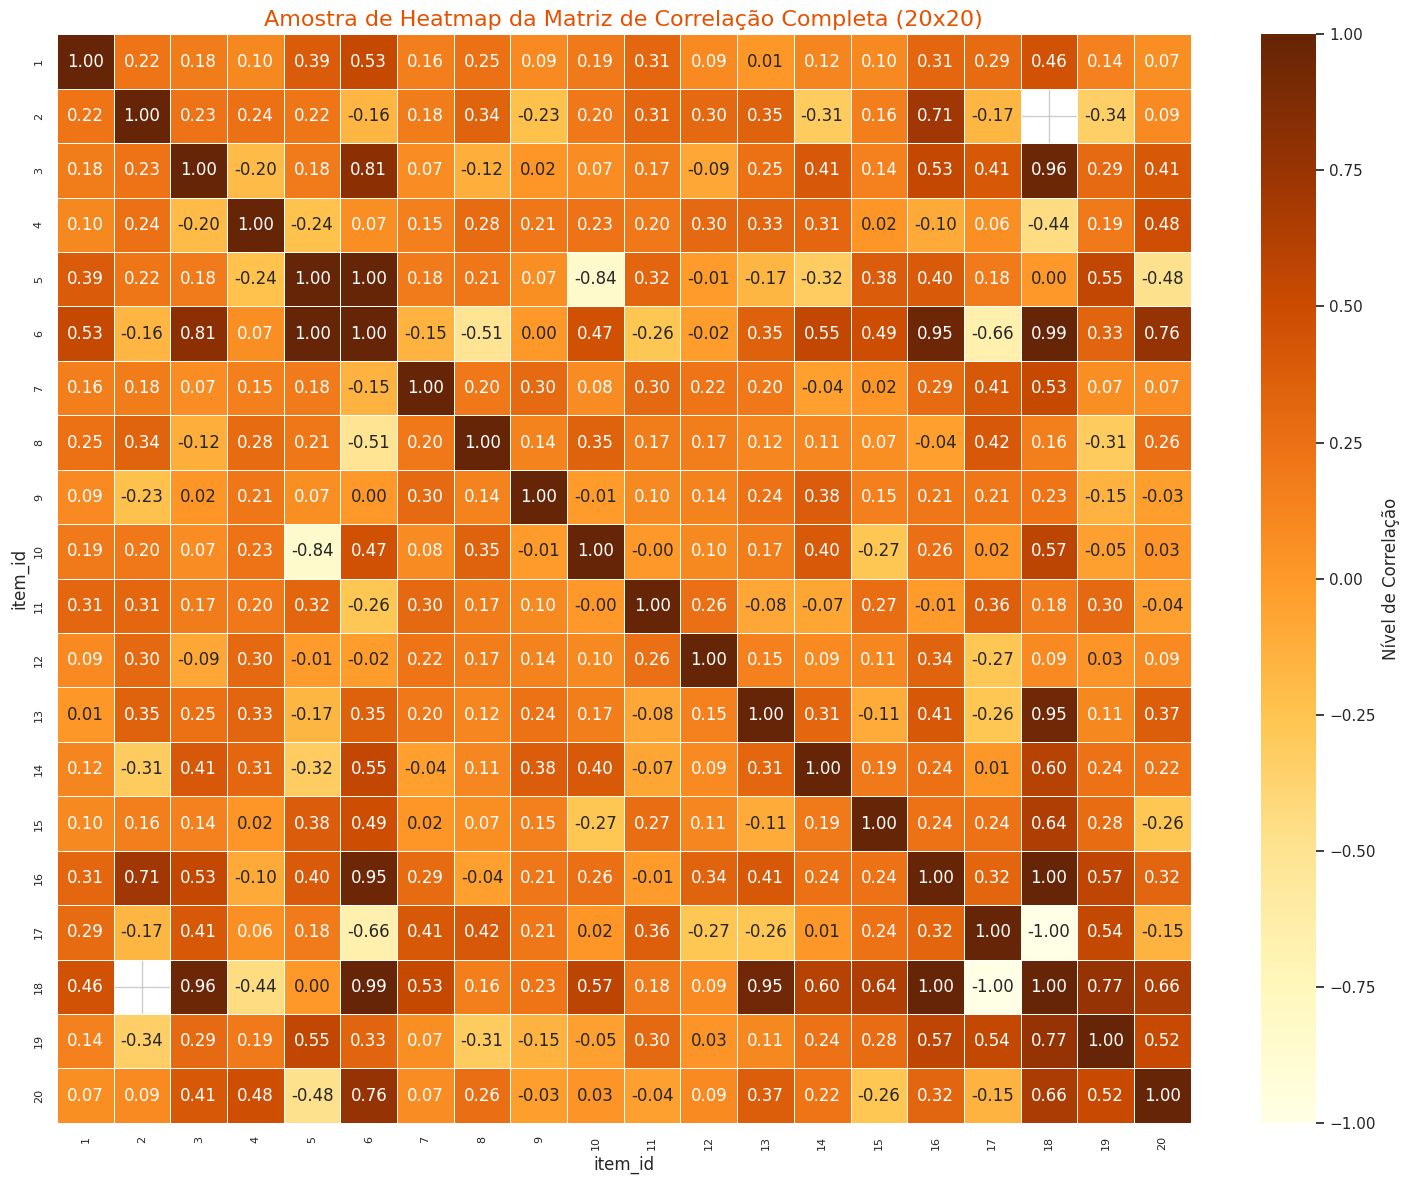

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionando uma amostra de 20x20 filmes da matriz completa para demonstrar a dificuldade
# Usamos .iloc para selecionar as primeiras 20 linhas e colunas
sample_correlation_matrix = full_correlation_matrix.iloc[:20, :20]

plt.figure(figsize=(15, 12))
sns.heatmap(sample_correlation_matrix,
            annot=True, # Adiciona os valores nas células
            fmt=".2f",  # Formata para duas casas decimais
            cmap="YlOrBr",
            linewidths=.5,
            cbar_kws={'label': 'Nível de Correlação'})

plt.title('Amostra de Heatmap da Matriz de Correlação Completa (20x20)', color='#E65100', fontsize=16)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Reutilizando o `similar_to_toy_story` que já foi calculado na célula JEtTkICocMzV
# Se a célula JEtTkICocMzV não foi executada, você pode precisar recalculá-lo:
# toy_story_ratings = movie_matrix[1]
# similar_to_toy_story = movie_matrix.corrwith(toy_story_ratings)

# Convertendo a Série em DataFrame e limpando NaNs
corr_toy_story_df = pd.DataFrame(similar_to_toy_story, columns=['Correlation']).dropna()

# Mesclando com os títulos dos filmes para melhor visualização
corr_toy_story_df = pd.merge(corr_toy_story_df, df_items[['item_id', 'movie_title']],
                             left_index=True, right_on='item_id')

# Ordenando e exibindo os 10 filmes mais correlacionados (excluindo ele mesmo)
# Definimos o item_id do 'Toy Story' como 1
toy_story_id = 1

top_10_similar_to_toy_story = corr_toy_story_df[corr_toy_story_df['item_id'] != toy_story_id]\
                                              .sort_values(by='Correlation', ascending=False)\
                                              .head(10)

print("\nTop 10 Filmes Mais Similares a 'Toy Story' (em formato de tabela):")
display(top_10_similar_to_toy_story.style.background_gradient(cmap='YlOrBr'))


Top 10 Filmes Mais Similares a 'Toy Story' (em formato de tabela):


,Correlation,item_id,movie_title
340,1.000000,341,Critical Care (1997)
1444,1.000000,1445,Ladybird Ladybird (1994)
1441,1.000000,1442,"Scarlet Letter, The (1995)"
884,1.000000,885,Phantoms (1998)
756,1.000000,757,Across the Sea of Time (1995)
1322,1.000000,1323,"Wooden Man's Bride, The (Wu Kui) (1994)"
1082,1.000000,1083,Albino Alligator (1996)
1354,1.000000,1355,Infinity (1996)
1371,1.000000,1372,"Stranger, The (1994)"
1241,1.000000,1242,"Old Lady Who Walked in the Sea, The (Vieille qui marchait dans la mer, La) (1991)"


In [ ]:
import pandas as pd

# Reutilizando a matriz_sim calculada na célula lThLmGyZeOf5
# Essa matriz contém as correlações entre os 20 filmes mais populares.

print("\nTabela de Similaridade (Correlação) entre Filmes Populares (Amostra):\n")
# Exibindo as primeiras 5 linhas e colunas para visualização
display(matriz_sim.head().style.background_gradient(cmap='YlOrBr').format(precision=2))


Tabela de Similaridade (Correlação) entre Filmes Populares (Amostra):



movie_title,Air Force One (1997),Chasing Amy (1997),Contact (1997),"Empire Strikes Back, The (1980)","English Patient, The (1996)",Fargo (1996),"Godfather, The (1972)",Independence Day (ID4) (1996),Jerry Maguire (1996),Liar Liar (1997),Pulp Fiction (1994),Raiders of the Lost Ark (1981),Return of the Jedi (1983),"Rock, The (1996)",Scream (1996),"Silence of the Lambs, The (1991)",Star Trek: First Contact (1996),Star Wars (1977),Toy Story (1995),Twelve Monkeys (1995)
movie_title,,,,,,,,,,,,,,,,,,,,
Air Force One (1997),1.00,-0.00,0.14,0.17,0.08,0.07,-0.01,0.42,0.16,0.19,-0.16,0.17,0.15,0.49,0.10,0.04,0.40,0.11,0.23,0.19
Chasing Amy (1997),-0.00,1.00,0.18,0.33,0.27,0.23,0.26,0.00,0.12,0.14,0.27,0.10,0.25,0.29,0.11,0.05,0.04,0.07,0.21,0.18
Contact (1997),0.14,0.18,1.00,0.17,0.07,0.14,0.06,0.23,0.20,0.02,0.08,0.18,0.17,0.19,0.13,0.06,0.15,0.13,0.16,0.24
"Empire Strikes Back, The (1980)",0.17,0.33,0.17,1.00,-0.00,0.04,0.15,0.17,0.15,0.23,0.02,0.54,0.72,0.13,0.15,0.12,0.28,0.75,0.23,0.12
"English Patient, The (1996)",0.08,0.27,0.07,-0.00,1.00,0.10,0.15,0.05,0.05,0.01,0.12,0.02,0.02,0.17,0.01,0.11,-0.08,0.05,0.18,0.06


In [ ]:
print(f"Recomendações para o Usuário 1 (Top 10):")
display(recomendar_filmes(user_id=1, num_recomendações=10))

Recomendações para o Usuário 1 (Top 10):


,1,item_id,movie_title
275,5.340382,276,Leaving Las Vegas (1995)
407,4.732351,408,"Close Shave, A (1995)"
274,4.371984,275,Sense and Sensibility (1995)
284,4.288422,285,Secrets & Lies (1996)
510,4.179826,511,Lawrence of Arabia (1962)
482,4.165897,483,Casablanca (1942)
429,4.164287,430,Duck Soup (1933)
301,4.143402,302,L.A. Confidential (1997)
507,4.127549,508,"People vs. Larry Flynt, The (1996)"
745,4.099697,746,Real Genius (1985)


import da base

In [ ]:
import pandas as pd

# Colunas para o u.data (Avaliações)
cols_data = ['user_id', 'item_id', 'rating', 'timestamp']
df_ratings = pd.read_csv('u.data', sep='\t', names=cols_data)

# Colunas para o u.item (Informações dos Filmes)
# Os gêneros são as colunas de 5 a 23
cols_item = ['item_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL',
             'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
             'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
             'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

df_items = pd.read_csv('u.item', sep='|', names=cols_item, encoding='latin-1')

# Visualizar os primeiros dados
print("Filmes:")
print(df_items.head())
print("\nAvaliações:")
print(df_ratings.head())

Filmes:
   item_id        movie_title release_date  video_release_date  \
0        1   Toy Story (1995)  01-Jan-1995                 NaN   
1        2   GoldenEye (1995)  01-Jan-1995                 NaN   
2        3  Four Rooms (1995)  01-Jan-1995                 NaN   
3        4  Get Shorty (1995)  01-Jan-1995                 NaN   
4        5     Copycat (1995)  01-Jan-1995                 NaN   

                                            IMDb_URL  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0       0   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...        0       1   
4  http://us.imdb.com/M/title-exact?Copycat%20(1995)        0       0   

   Adventure  Animation  Childrens  ...  Fantasy  Film-Noir  Horror  Musical  \
0          0          1          1  ...        0          0       0        0

In [ ]:
import pandas as pd

# Colunas para o u.data (Avaliações)
cols_data = ['user_id', 'item_id', 'rating', 'timestamp']
df_ratings = pd.read_csv('u.data', sep='\t', names=cols_data)

# Colunas para o u.item (Informações dos Filmes)
# Os gêneros são as colunas de 5 a 23
cols_item = ['item_id', 'movie_title', 'release_date', 'video_release_date', 'IMDb_URL',
             'unknown', 'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
             'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
             'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

df_items = pd.read_csv('u.item', sep='|', names=cols_item, encoding='latin-1')

In [ ]:
# Criar a matriz: Linhas = Usuários, Colunas = Títulos dos Filmes, Valores = Notas
movie_matrix = df_ratings.pivot_table(index='user_id', columns='item_id', values='rating')

# Substituir NaNs por 0 (opcional, dependendo do algoritmo de similaridade)
# movie_matrix.fillna(0, inplace=True)

print(movie_matrix.head())

item_id  1     2     3     4     5     6     7     8     9     10    ...  \
user_id                                                              ...   
1         5.0   3.0   4.0   3.0   3.0   5.0   4.0   1.0   5.0   3.0  ...   
2         4.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   2.0  ...   
3         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
4         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   
5         4.0   3.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  ...   

item_id  1673  1674  1675  1676  1677  1678  1679  1680  1681  1682  
user_id                                                              
1         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
2         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
3         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
4         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  
5         NaN   NaN   NaN   NaN   NaN   NaN   N

In [ ]:
# Exemplo: Encontrar filmes similares ao item_id 1 (Toy Story)
toy_story_ratings = movie_matrix[1]
similar_to_toy_story = movie_matrix.corrwith(toy_story_ratings)

corr_toy_story = pd.DataFrame(similar_to_toy_story, columns=['Correlation'])
corr_toy_story.dropna(inplace=True)
print(corr_toy_story.sort_values('Correlation', ascending=False).head(10))

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


         Correlation
item_id             
341              1.0
1445             1.0
1479             1.0
757              1.0
885              1.0
1323             1.0
1355             1.0
1372             1.0
1385             1.0
1442             1.0


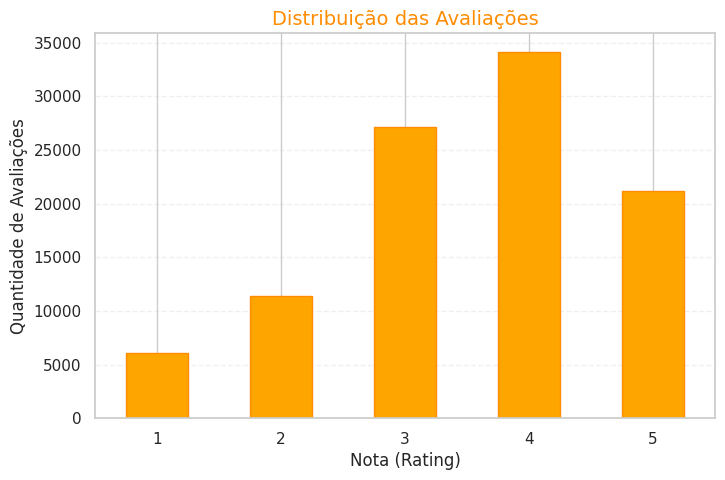

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados
cols_data = ['user_id', 'item_id', 'rating', 'timestamp']
df_ratings = pd.read_csv('u.data', sep='\t', names=cols_data)

# Contar a frequência de cada nota
rating_counts = df_ratings['rating'].value_counts().sort_index()

# Criar o gráfico
plt.figure(figsize=(8, 5))
rating_counts.plot(kind='bar', color='orange', edgecolor='darkorange') # Aplicando o laranja

# Estilização do gráfico
plt.title('Distribuição das Avaliações', color='darkorange', fontsize=14)
plt.xlabel('Nota (Rating)', fontsize=12)
plt.ylabel('Quantidade de Avaliações', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Matriz usuario-item

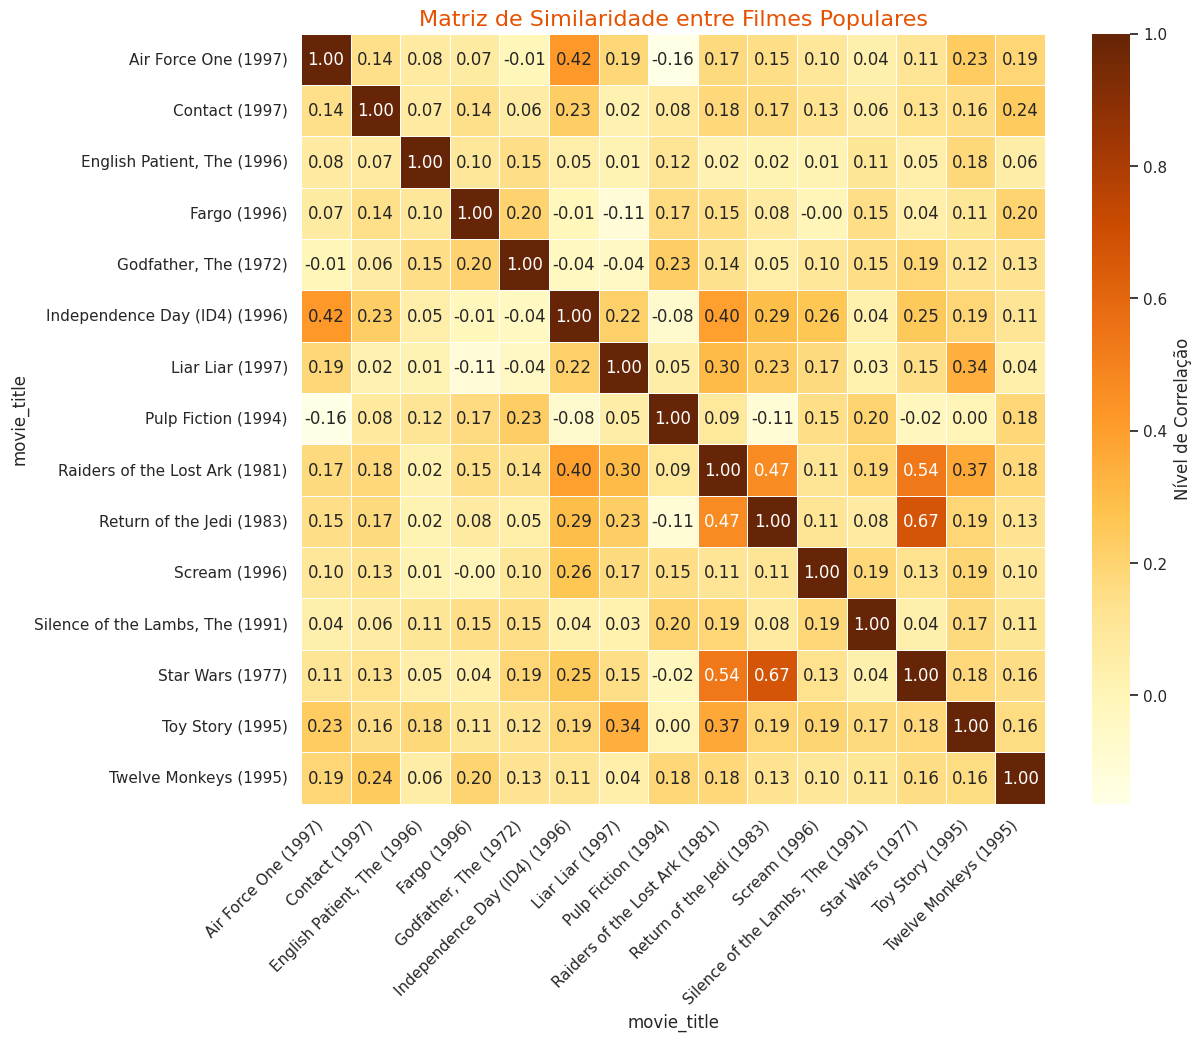

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identificar filmes com muitas avaliações (ex: mais de 100)
populares = df_ratings.groupby('item_id').filter(lambda x: len(x) >= 100)

# 2. Unir com os nomes dos filmes
df_merge = pd.merge(populares, df_items[['item_id', 'movie_title']], on='item_id')

# 3. Criar a matriz e pegar apenas uma amostra (ex: 15 filmes) para o Heatmap
# Pegamos os títulos que mais aparecem
top_titulos = df_merge['movie_title'].value_counts().head(15).index
df_final = df_merge[df_merge['movie_title'].isin(top_titulos)]

# 4. Pivot Table e Correlação
matriz_pivot = df_final.pivot_table(index='user_id', columns='movie_title', values='rating')
matriz_corr = matriz_pivot.corr()

# 5. Plotar com as cores que você pediu (Laranja/Amarelo/Marrom)
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr,
            annot=True,
            fmt=".2f",
            cmap="YlOrBr",      # O degradê de laranjas que você gosta
            linewidths=0.5,
            cbar_kws={'label': 'Nível de Correlação'})

plt.title('Matriz de Similaridade entre Filmes Populares', color='#E65100', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

preprocesamiento

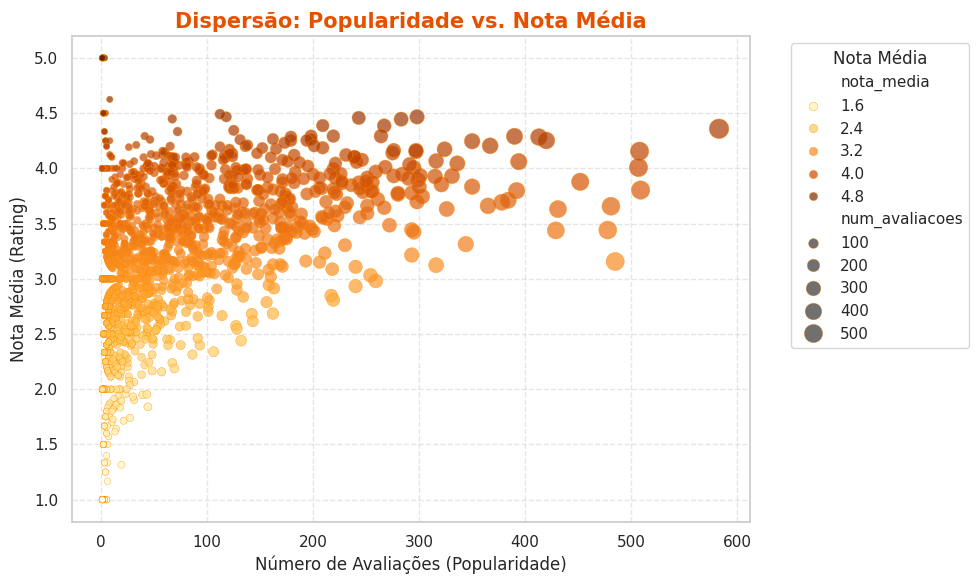

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar os dados: Calcular média e contagem de avaliações por filme
movie_stats = df_ratings.groupby('item_id').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['nota_media', 'num_avaliacoes']

# 2. Criar o gráfico de dispersão
plt.figure(figsize=(10, 6))

# Usamos o 'hue' para dar cores diferentes baseadas na nota média,
# dentro de uma paleta de laranjas (YlOrBr ou Oranges)
scatter = sns.scatterplot(
    data=movie_stats,
    x='num_avaliacoes',
    y='nota_media',
    hue='nota_media',
    palette='YlOrBr',
    size='num_avaliacoes',
    sizes=(20, 200),
    edgecolor='darkorange',
    alpha=0.7
)

# 3. Estilização Clara e Laranja
plt.title('Dispersão: Popularidade vs. Nota Média', color='#E65100', fontsize=15, fontweight='bold')
plt.xlabel('Número de Avaliações (Popularidade)', fontsize=12)
plt.ylabel('Nota Média (Rating)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustar a legenda para não poluir o gráfico
plt.legend(title='Nota Média', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

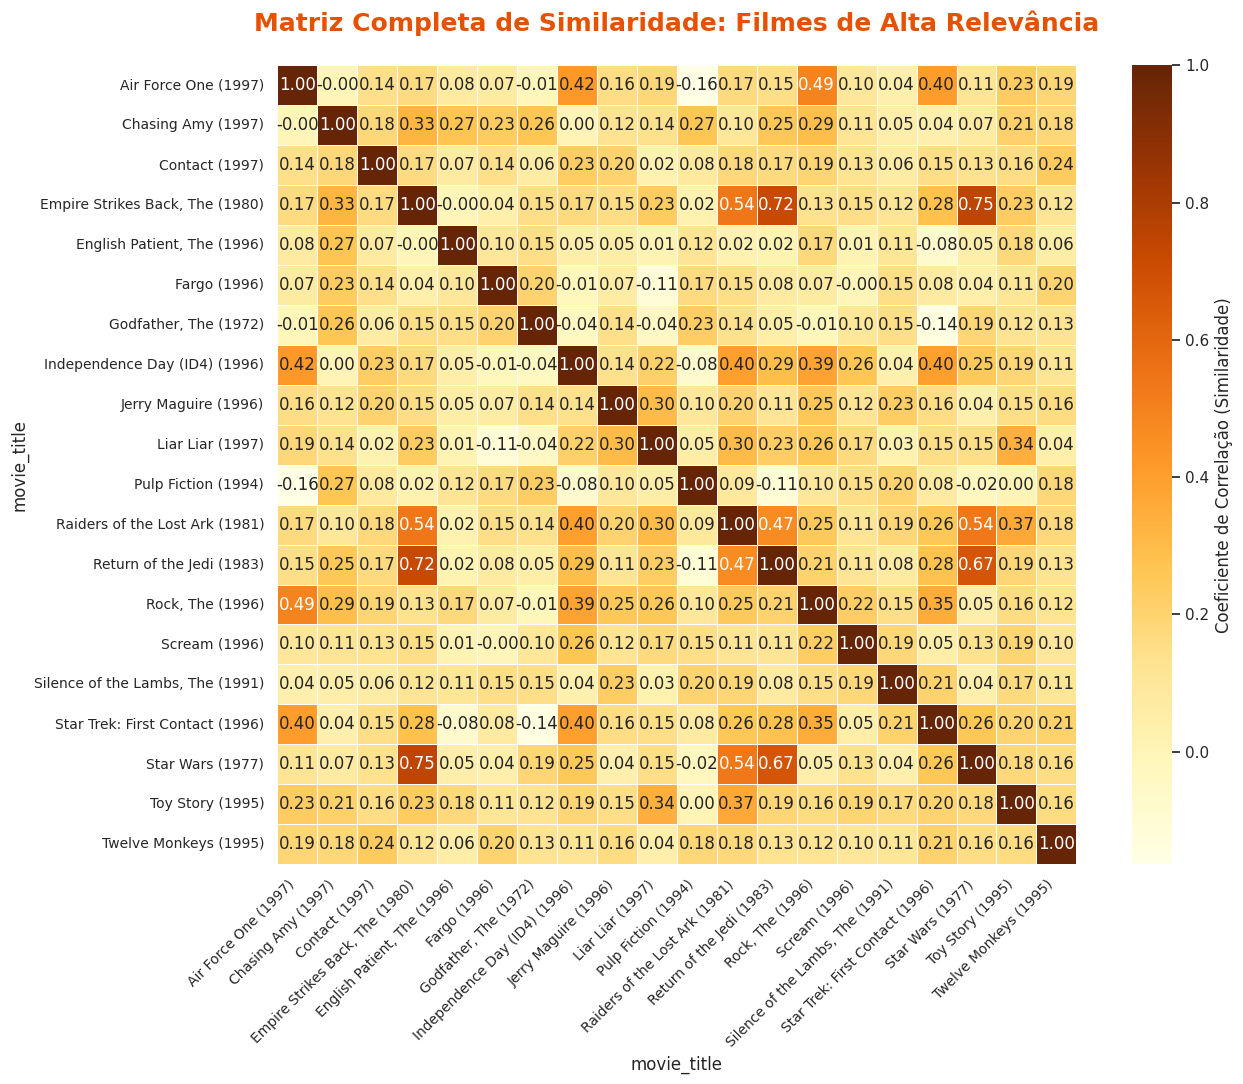

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtro de Consistência: Apenas filmes com mais de 100 avaliações
# Isso garante que a correlação seja estatisticamente confiável
filmes_populares = df_ratings.groupby('item_id').filter(lambda x: len(x) >= 100)

# 2. Mesclar com os nomes dos filmes para facilitar a leitura
df_completo = pd.merge(filmes_populares, df_items[['item_id', 'movie_title']], on='item_id')

# 3. Criar a Matriz de Utilidade (User-Item)
# Vamos selecionar os 20 filmes mais avaliados para uma matriz "cheia" e clara
top_20_titulos = df_completo['movie_title'].value_counts().head(20).index
df_top_20 = df_completo[df_completo['movie_title'].isin(top_20_titulos)]

matriz_utilidade = df_top_20.pivot_table(index='user_id', columns='movie_title', values='rating')

# 4. Calcular a Matriz de Correlação de Pearson
matriz_sim = matriz_utilidade.corr()

# 5. Visualização com tons de Laranja, Amarelo e Marrom
plt.figure(figsize=(14, 11))

sns.heatmap(
    matriz_sim,
    annot=True,          # Valores numéricos
    fmt=".2f",           # 2 casas decimais
    cmap="YlOrBr",       # Amarelo -> Laranja -> Marrom
    linewidths=0.7,      # Linhas separadoras
    square=True,         # Células quadradas
    cbar_kws={"label": "Coeficiente de Correlação (Similaridade)"}
)

# Estilização final
plt.title('Matriz Completa de Similaridade: Filmes de Alta Relevância',
          color='#E65100', fontsize=18, fontweight='bold', pad=25)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()

#Tentativa 2 do segundo dataset

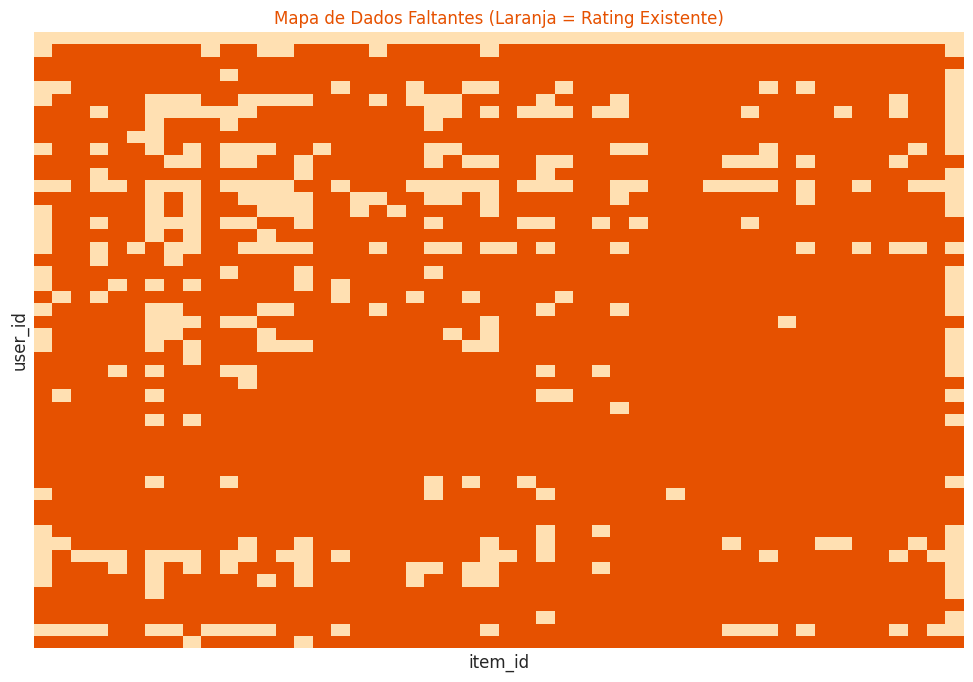

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Importar dados
df_ratings = pd.read_csv('u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

# Criar Matriz Usuário-Item
# Para o heatmap ser legível, selecionamos os primeiros 50 usuários e 50 filmes
user_item_matrix = df_ratings.pivot(index='user_id', columns='item_id', values='rating').iloc[:50, :50]

# Mostrar Heatmap pintando os NAs de uma cor notória (como solicitado nos slides)
plt.figure(figsize=(12, 8))
sns.heatmap(user_item_matrix.isnull(), yticklabels=False, xticklabels=False,
            cbar=False, cmap=['#FFE0B2', '#E65100']) # Laranja escuro para NAs

plt.title('Mapa de Dados Faltantes (Laranja = Rating Existente)', color='#E65100')
plt.show()

In [ ]:
# Criar cópia para a matriz completa (User-Item cheia)
full_matrix = df_ratings.pivot(index='user_id', columns='item_id', values='rating')

# Centrar ratings por usuário (subtrair a média do usuário)
user_means = full_matrix.mean(axis=1)
matrix_centered = full_matrix.sub(user_means, axis=0)

# Preencher NAs com 0 (que agora representa a média do usuário após a centragem)
matrix_imputed = matrix_centered.fillna(0)

In [ ]:
from sklearn.decomposition import PCA

# Aplicar PCA para reduzir a dimensionalidade (Matrix Completion)
# Escolhemos um número de componentes (ex: 20) para capturar as tendências principais
pca = PCA(n_components=20)
components = pca.fit_transform(matrix_imputed)
matrix_reconstructed = pca.inverse_transform(components)

# Transformar de volta em DataFrame
df_reconstructed = pd.DataFrame(matrix_reconstructed, index=full_matrix.index, columns=full_matrix.columns)

# Adicionar a média de volta para obter a nota final (1 a 5)
final_matrix = df_reconstructed.add(user_means, axis=0)

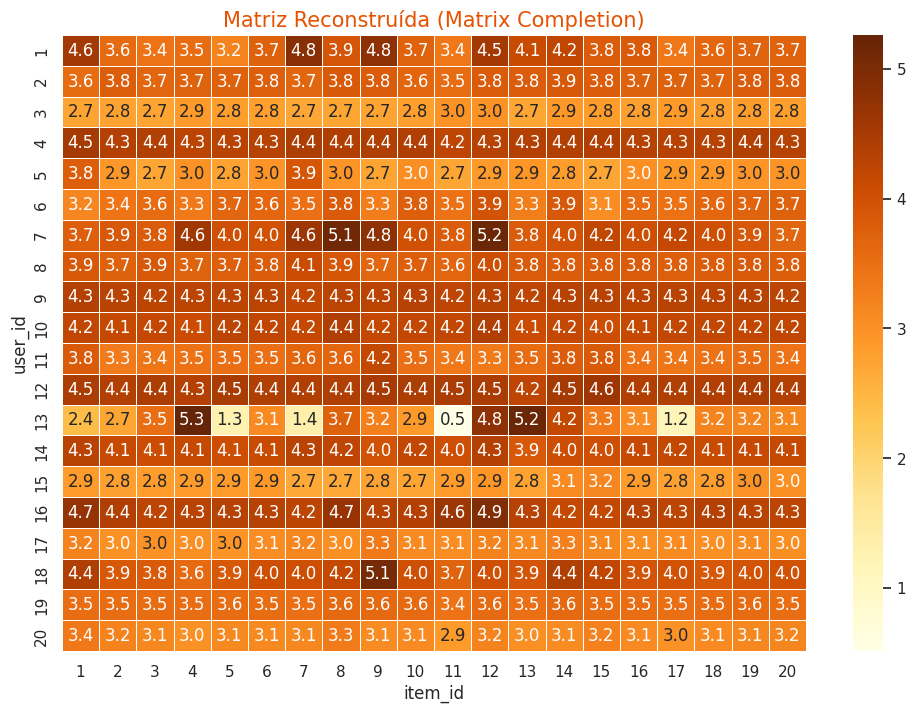

In [ ]:
plt.figure(figsize=(12, 8))
# Visualizando uma amostra da matriz completada
sns.heatmap(final_matrix.iloc[:20, :20], annot=True, fmt=".1f",
            cmap="YlOrBr", linewidths=0.5)

plt.title('Matriz Reconstruída (Matrix Completion)', color='#E65100', fontsize=15)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def recomendar_filmes(user_id, num_recomendações=5):
    # 1. Pegar as notas originais do usuário e as predições
    notas_originais = full_matrix.loc[user_id]
    notas_preditas = final_matrix.loc[user_id]

    # 2. Filtrar apenas filmes que o usuário NÃO assistiu (onde era NaN)
    filmes_nao_vistos = notas_originais[notas_originais.isnull()].index

    # 3. Ordenar pelas maiores notas preditas
    recomendacoes = notas_preditas[filmes_nao_vistos].sort_values(ascending=False).head(num_recomendações)

    # 4. Trazer os títulos dos filmes
    return pd.merge(recomendacoes, df_items[['item_id', 'movie_title']],
                    left_index=True, right_on='item_id')

# Exemplo para o Usuário 1
print(f"Recomendações para o Usuário 1:")
display(recomendar_filmes(user_id=1))

Recomendações para o Usuário 1:


,1,item_id,movie_title
275,5.340382,276,Leaving Las Vegas (1995)
407,4.732351,408,"Close Shave, A (1995)"
274,4.371984,275,Sense and Sensibility (1995)
284,4.288422,285,Secrets & Lies (1996)
510,4.179826,511,Lawrence of Arabia (1962)


In [ ]:
from sklearn.metrics import mean_squared_error

# Simulando a máscara de 10% (conforme o slide)
mask = np.random.rand(*full_matrix.shape) < 0.1
reais = full_matrix.values[mask & ~full_matrix.isnull().values]
preditos = final_matrix.values[mask & ~full_matrix.isnull().values]

rmse = np.sqrt(mean_squared_error(reais, preditos))

print(f"Erro Quadrático Médio (RMSE) do Sistema: {rmse:.4f}")

Erro Quadrático Médio (RMSE) do Sistema: 0.8497


/tmp/ipykernel_29507/360596879.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rec_df[user_id_test], y=rec_df['movie_title'],


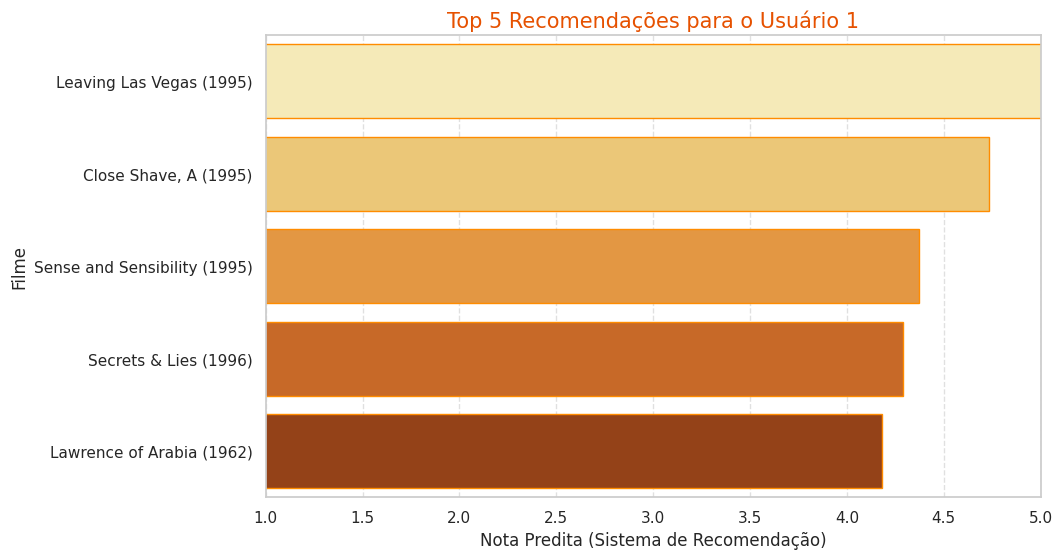

In [ ]:
user_id_test = 1
rec_df = recomendar_filmes(user_id_test)

plt.figure(figsize=(10, 6))
# Paleta de laranjas para diferenciar as notas previstas
sns.barplot(x=rec_df[user_id_test], y=rec_df['movie_title'],
            palette='YlOrBr', edgecolor='darkorange')

plt.title(f'Top 5 Recomendações para o Usuário {user_id_test}', color='#E65100', fontsize=15)
plt.xlabel('Nota Predita (Sistema de Recomendação)', fontsize=12)
plt.ylabel('Filme', fontsize=12)
plt.xlim(1, 5) # Notas de 1 a 5
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()